<a href="https://colab.research.google.com/github/brahmani2008/Nasscom-lab/blob/main/U6_%E2%80%94_Probability_%26_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)


total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [ ]:
# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 1. Numerical vs categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

# 2. Mean of a numerical column (tip)
mean_tip = df['tip'].mean()
print("\nMean of tip:")
print(mean_tip)

# 3. Value counts of a categorical column (sex)
sex_counts = df['sex'].value_counts()

print("\nValue counts of sex:")
print(sex_counts)

Numerical columns:
Index(['total_bill', 'tip', 'size'], dtype='object')

Categorical columns:
Index(['sex', 'smoker', 'day', 'time'], dtype='object')

Mean of tip:
2.99827868852459

Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


In [ ]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value


Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


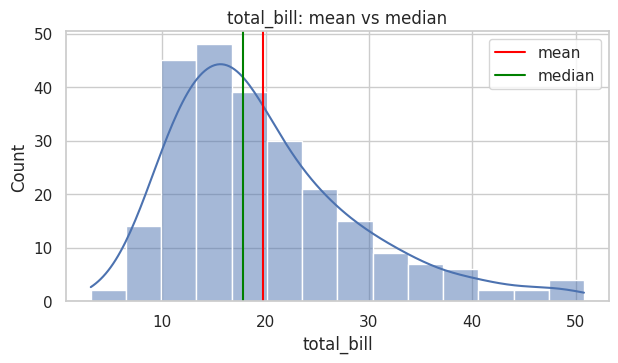

In [ ]:
# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()



Mean: 2.99827868852459
Median: 2.9
Mode:
0    2.0
Name: tip, dtype: float64

Is mean > median?
True


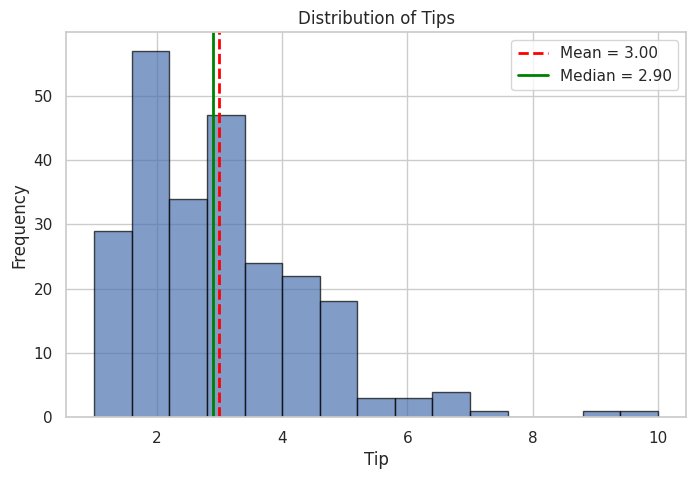

In [ ]:
import matplotlib.pyplot as plt

tip = df['tip']

# 1. Mean, median, mode
mean_tip = tip.mean()
median_tip = tip.median()
mode_tip = tip.mode()

print("Mean:", mean_tip)
print("Median:", median_tip)
print("Mode:")
print(mode_tip)

# 2. Is mean > median?
print("\nIs mean > median?")
print(mean_tip > median_tip)

# 3. Histogram with mean & median lines
plt.figure(figsize=(8, 5))

plt.hist(tip, bins=15, edgecolor='black', alpha=0.7)

plt.axvline(mean_tip, color='red', linestyle='--',
            linewidth=2, label=f'Mean = {mean_tip:.2f}')

plt.axvline(median_tip, color='green', linestyle='-',
            linewidth=2, label=f'Median = {median_tip:.2f}')

plt.title("Distribution of Tips")
plt.xlabel("Tip")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)

Range : 47.74
Var   : 79.25
Std   : 8.9


In [ ]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [ ]:
tip = df['tip']

# 1. Range, variance, standard deviation
tip_range = tip.max() - tip.min()
variance = tip.var()
std_dev = tip.std()

print("Range:", tip_range)
print("Variance:", variance)
print("Standard Deviation:", std_dev)

# 2. Q1, Q3, IQR
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# 3. Most robust measure of spread
print("\nMost robust measure of spread: Interquartile Range (IQR)")

Range: 9.0
Variance: 1.9144546380624725
Standard Deviation: 1.3836381890011826

Q1: 2.0
Q3: 3.5625
IQR: 1.5625

Most robust measure of spread: Interquartile Range (IQR)


In [ ]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


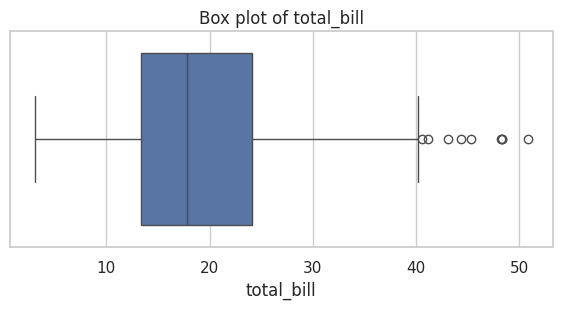

In [ ]:
# The box spans Q1..Q3 (the IQR), the line is the median,
# whiskers reach the rest, and dots beyond them are outliers.
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

Five-number summary:
Minimum: 1.0
Q1: 2.0
Median: 2.9
Q3: 3.5625
Maximum: 10.0

Skewness: 1.4654510370979401
Distribution is positively (right) skewed.


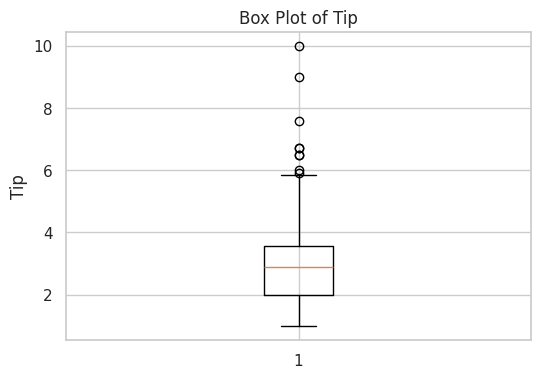

In [ ]:
import matplotlib.pyplot as plt

tip = df['tip']

# 1. Five-number summary
minimum = tip.min()
Q1 = tip.quantile(0.25)
median = tip.median()
Q3 = tip.quantile(0.75)
maximum = tip.max()

print("Five-number summary:")
print("Minimum:", minimum)
print("Q1:", Q1)
print("Median:", median)
print("Q3:", Q3)
print("Maximum:", maximum)

# 2. Skewness (+ comment)
skewness = tip.skew()

print("\nSkewness:", skewness)

if skewness > 0:
    print("Distribution is positively (right) skewed.")
elif skewness < 0:
    print("Distribution is negatively (left) skewed.")
else:
    print("Distribution is approximately symmetric.")

# 3. Box plot of tip
plt.figure(figsize=(6, 4))
plt.boxplot(tip, vert=True)

plt.title("Box Plot of Tip")
plt.ylabel("Tip")
plt.grid(True)

plt.show()

In [ ]:
# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


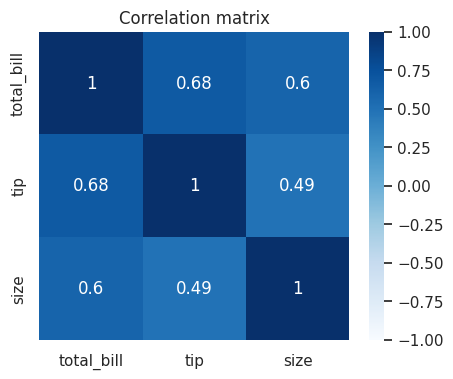

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()


In [ ]:
# describe() returns count, mean, std, min, quartiles and max for every numeric column
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


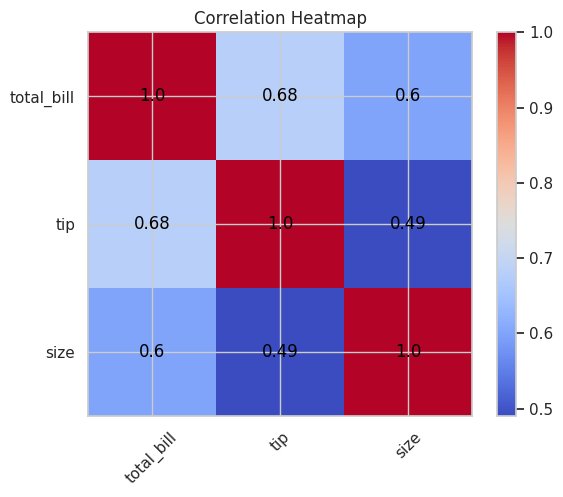


df.describe():
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Correlation matrix (rounded)
corr_matrix = df.corr(numeric_only=True).round(2)

print("Correlation Matrix:")
print(corr_matrix)

# 2. Heatmap of the correlation matrix
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Display correlation values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, corr_matrix.iloc[i, j],
                 ha='center', va='center', color='black')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3. Summary statistics
summary = df.describe()

print("\ndf.describe():")
print(summary)

# Insight 1: Numeric columns with larger standard deviations have greater variability.
# Insight 2: If mean > median for a column (e.g., tip), the distribution is likely right-skewed.
# Insight 3: Correlation values close to +1 or -1 indicate strong relationships, while values near 0 indicate weak or no linear relationship.